In [ ]:
!pip install pyspark --quiet
print('pyspark installation complete')

pyspark installation complete


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
spark=SparkSession.builder \
  .appName('Day4 bigdata sales') \
  .config('spark.sql.adaptive.enabled','true') \
  .getOrCreate()
print(f'spark version: {spark.version}')
print(f'spark session:ACTIVE')
print(f'application name: {spark.conf.get("spark.app.name")}')

spark version: 4.0.2
spark session:ACTIVE
application name: Day4 bigdata sales


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving large_sales_data.csv to large_sales_data.csv


In [ ]:
df_bronze=spark.read \
.option('header','true') \
.option('inferSchema','true') \
.csv('large_sales_data.csv')
print('=== bronze layer -raw data ===')
print(f'rows: {df_bronze.count()}')
print(f'columns: {len(df_bronze.columns)}')
print(f'names:{df_bronze.columns}')
print()
df_bronze.printSchema()

=== bronze layer -raw data ===
rows: 5000
columns: 13
names:['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print('First 5 rows:')
df_bronze.show(5,truncate=False)

print('\nBasic statistics for numeric columns:')
df_bronze.select('quantity','unit_price','revenue').describe().show()

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [ ]:
df_bronze.write \
  .mode('overwrite') \
  .parquet('sales_bronze.parquet')

print('Bronze Parquet saved: sales_bronze.parquet')

#compare file_sizes
import os

def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.isfile(path)
  total=0
  for dirpath,dirnames,filenames in os.walk(path):
    for f in filenames:
      total+=os.path.getsize(os.path.join(dirpath,f))
    return total/1024

csv_size=get_dir_size('large_sales_data.csv')
parquet_size=get_dir_size('sales_bronze.parquet')
reduction=(1-parquet_size/csv_size)*100
print(f'\ncsv file size: {csv_size:.1f} KB')
print(f'parquet file size: {parquet_size:.1f} KB')
print(f'reduction in size: {reduction:.1f}% smaller')
print(f'\nAt 1TB scale: CSV=1000GB -> Parquet={1000*(1-reduction/100):.0f} GB')

Bronze Parquet saved: sales_bronze.parquet

csv file size: 1.0 KB
parquet file size: 55.1 KB
reduction in size: -5409.8% smaller

At 1TB scale: CSV=1000GB -> Parquet=55098 GB


In [ ]:
df_silver=df_bronze \
  .dropDuplicates() \
  .dropna(subset=['order_id','product','revenue'])

df_silver=df_silver.withColumn(
     'order_date',to_date(col('order_date'),'yyyy-MM-dd')
  )

df_silver=df_silver \
  .withColumn('order_year',year('order_date')) \
  .withColumn('order_month',month('order_date'))

df_silver=df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue')>40000,'High')
    .when(col('revenue')>10000,'Medium')
    .otherwise('Low')
)

print(f'Silver layer rows:{df_silver.count()}')
print(f'New columns added: order_year ,order_month,revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category').show()

Silver layer rows:5000
New columns added: order_year ,order_month,revenue_category
+----------+-------+----------+-----------+----------------+
|   product|revenue|order_year|order_month|revenue_category|
+----------+-------+----------+-----------+----------------+
|  Keyboard|  13200|      2023|          2|          Medium|
|    Webcam|  17500|      2023|          1|          Medium|
|   Speaker|  58500|      2023|          4|            High|
|  Keyboard|   9600|      2023|         12|             Low|
|    Laptop| 180000|      2023|          8|            High|
|Headphones|  38500|      2023|          5|          Medium|
|    Webcam|  35000|      2023|         11|          Medium|
|    Laptop| 360000|      2023|          1|            High|
|    Tablet| 320000|      2023|          6|            High|
|    Laptop| 225000|      2023|          6|            High|
|     Mouse|   6400|      2023|          8|             Low|
|   Monitor| 132000|      2023|          7|            High|
| 

In [ ]:
df_silver.write \
  .mode('overwrite') \
  .parquet('sales_silver.parquet')

print('Silver Parquet saved: sales_silver.parquet')
print(f'Silver size: {get_dir_size("sales_silver.parquet"):.1f} KB')

df_verify=spark.read.parquet('sales_silver.parquet')
print('\n===Verify Silver layer===')
print(f'Read back rows:{df_verify.count()} (should match silver count)')
df_verify.printSchema()

Silver Parquet saved: sales_silver.parquet
Silver size: 59.8 KB

===Verify Silver layer===
Read back rows:5000 (should match silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [ ]:
top_products = df_silver \
  .groupBy('product') \
  .agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('num_orders'),
    F.avg('revenue').alias('avg_order_revenue')
  ) \
  .orderBy('total_revenue',ascending=False) \
  .limit(5)

print('=== top 5 product by revenue ===')
top_products.show(truncate=False)

=== top 5 product by revenue ===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders|avg_order_revenue |
+-------+-------------+----------+------------------+
|Laptop |182700000    |502       |363944.22310756973|
|Tablet |135104000    |532       |253954.8872180451 |
|Monitor|82126000     |481       |170740.12474012474|
|Printer|44544000     |488       |91278.68852459016 |
|Speaker|16317000     |470       |34717.02127659575 |
+-------+-------------+----------+------------------+



In [ ]:
region_revenue=df_silver \
  .groupBy('region') \
  .agg(
      F.sum('revenue').alias('total_revenue'),
      F.count('order_id').alias('total_orders'),
      F.countDistinct('customer_name').alias('unique_customers')
  ) \
  .orderBy('total_revenue',ascending=False) \
  .limit(5)

print('===Region wise revenue===')
region_revenue.show(truncate=False)

===Region wise revenue===
+------+-------------+------------+----------------+
|region|total_revenue|total_orders|unique_customers|
+------+-------------+------------+----------------+
|West  |198275600    |2021        |15              |
|South |147145900    |1483        |15              |
|North |99878400     |995         |15              |
|East  |50547700     |501         |15              |
+------+-------------+------------+----------------+



In [ ]:
unique_customer_names = df_silver.select('customer_name').distinct()

print('=== Unique Customer Names ===')
unique_customer_names.show(truncate=False)

=== Unique Customer Names ===
+-------------+
|customer_name|
+-------------+
|Amit Verma   |
|Tanvi Mehta  |
|Vikram Iyer  |
|Kavya Nambiar|
|Rahul Mishra |
|Suresh Rao   |
|Meera Joshi  |
|Priya Patel  |
|Ramesh Kumar |
|Sneha Reddy  |
|Kiran Kumar  |
|Ananya Das   |
|Pooja Gupta  |
|Divya Singh  |
|Arjun Nair   |
+-------------+



In [ ]:
monthly_trend = df_silver \
  .groupBy('order_month') \
  .agg(
      F.sum('revenue').alias('monthly_revenue'),
      F.count('order_id').alias('monthly_orders')
  ) \
  .orderBy('order_month')

print('=== Monthly Revenue Trend ===')
monthly_trend.show()

=== Monthly Revenue Trend ===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|          1|       41068200|           423|
|          2|       34485400|           375|
|          3|       40031200|           451|
|          4|       38857100|           390|
|          5|       39984500|           423|
|          6|       40707400|           390|
|          7|       42640700|           405|
|          8|       43718500|           418|
|          9|       37640200|           398|
|         10|       47839000|           479|
|         11|       44577100|           419|
|         12|       44298300|           429|
+-----------+---------------+--------------+



In [ ]:
monthly_trend = df_silver \
  .withColumn('order_month',F.date_format(F.col('order_date'),'MMMM')) \
  .groupBy('order_month') \
  .agg(
      F.sum('revenue').alias('monthly_revenue'),
      F.count('order_id').alias('monthly_orders')
  ) \
  .orderBy('order_month').d

print('=== Monthly Revenue Trend ===')
monthly_trend.show()

=== Monthly Revenue Trend ===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|      April|       38857100|           390|
|     August|       43718500|           418|
|   December|       44298300|           429|
|   February|       34485400|           375|
|    January|       41068200|           423|
|       July|       42640700|           405|
|       June|       40707400|           390|
|      March|       40031200|           451|
|        May|       39984500|           423|
|   November|       44577100|           419|
|    October|       47839000|           479|
|  September|       37640200|           398|
+-----------+---------------+--------------+



In [39]:
gold_region=region_revenue
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')
print('Gold 1 saved:gold_region_revenue.parquet')

gold_products = df_silver \
  .groupBy('product','category') \
  .agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('units_sold'),
    spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
    F.max('revenue').alias('largest_order')
  ) \
  .orderBy('total_revenue',ascending=False)

gold_products.write.mode('overwrite').parquet('gold_product_summary.parquet')
print('Gold 2 saved:gold_product_summary.parquet')


print('\nMedallion ')
print('Gold  -> gold_region_revenue.parquet')
print('      -> gold_product_summary.parquet')
print('      -> gold_product_summary.parquet')

#gold table 3 : monthly revenue trend
gold_monthly_trend = monthly_trend
gold_monthly_trend.write.mode('overwrite').parquet('gold_monthly_revenue_trend.parquet')
print('Gold 3 saved: gold_monthly_trend.parquet')

gold_products.show(truncate= False)

Gold 1 saved:gold_region_revenue.parquet
Gold 2 saved:gold_product_summary.parquet

Medallion 
Gold  -> gold_region_revenue.parquet
      -> gold_product_summary.parquet
      -> gold_product_summary.parquet
Gold 3 saved: gold_monthly_trend.parquet
+----------+-----------+-------------+----------+----------------------+-------------+
|product   |category   |total_revenue|units_sold|avg_quantity_per_order|largest_order|
+----------+-----------+-------------+----------+----------------------+-------------+
|Laptop    |Electronics|182700000    |502       |8.1                   |675000       |
|Tablet    |Electronics|135104000    |532       |7.9                   |480000       |
|Monitor   |Electronics|82126000     |481       |7.8                   |330000       |
|Printer   |Electronics|44544000     |488       |7.6                   |180000       |
|Speaker   |Electronics|16317000     |470       |7.7                   |67500        |
|Headphones|Electronics|13541500     |481       |8.0   

In [41]:
region_pd = spark.read.parquet('gold_region_revenue.parquet').toPandas()
product_pd = spark.read.parquet('gold_product_summary.parquet').toPandas()
monthly_pd = spark.read.parquet('gold_monthly_revenue_trend.parquet').toPandas()

print('Gold tables converted to Pandas:')
print(f'Region:{region_pd.shape}')
print(f'Product:{product_pd.shape}')
print(f'Monthly:{monthly_pd.shape}')

region_pd = region_pd.sort_values('total_revenue',ascending=False)
product_pd = product_pd.sort_values('total_revenue',ascending=False)
monthly_pd = monthly_pd.sort_values('order_month')



Gold tables converted to Pandas:
Region:(4, 4)
Product:(10, 6)
Monthly:(12, 3)


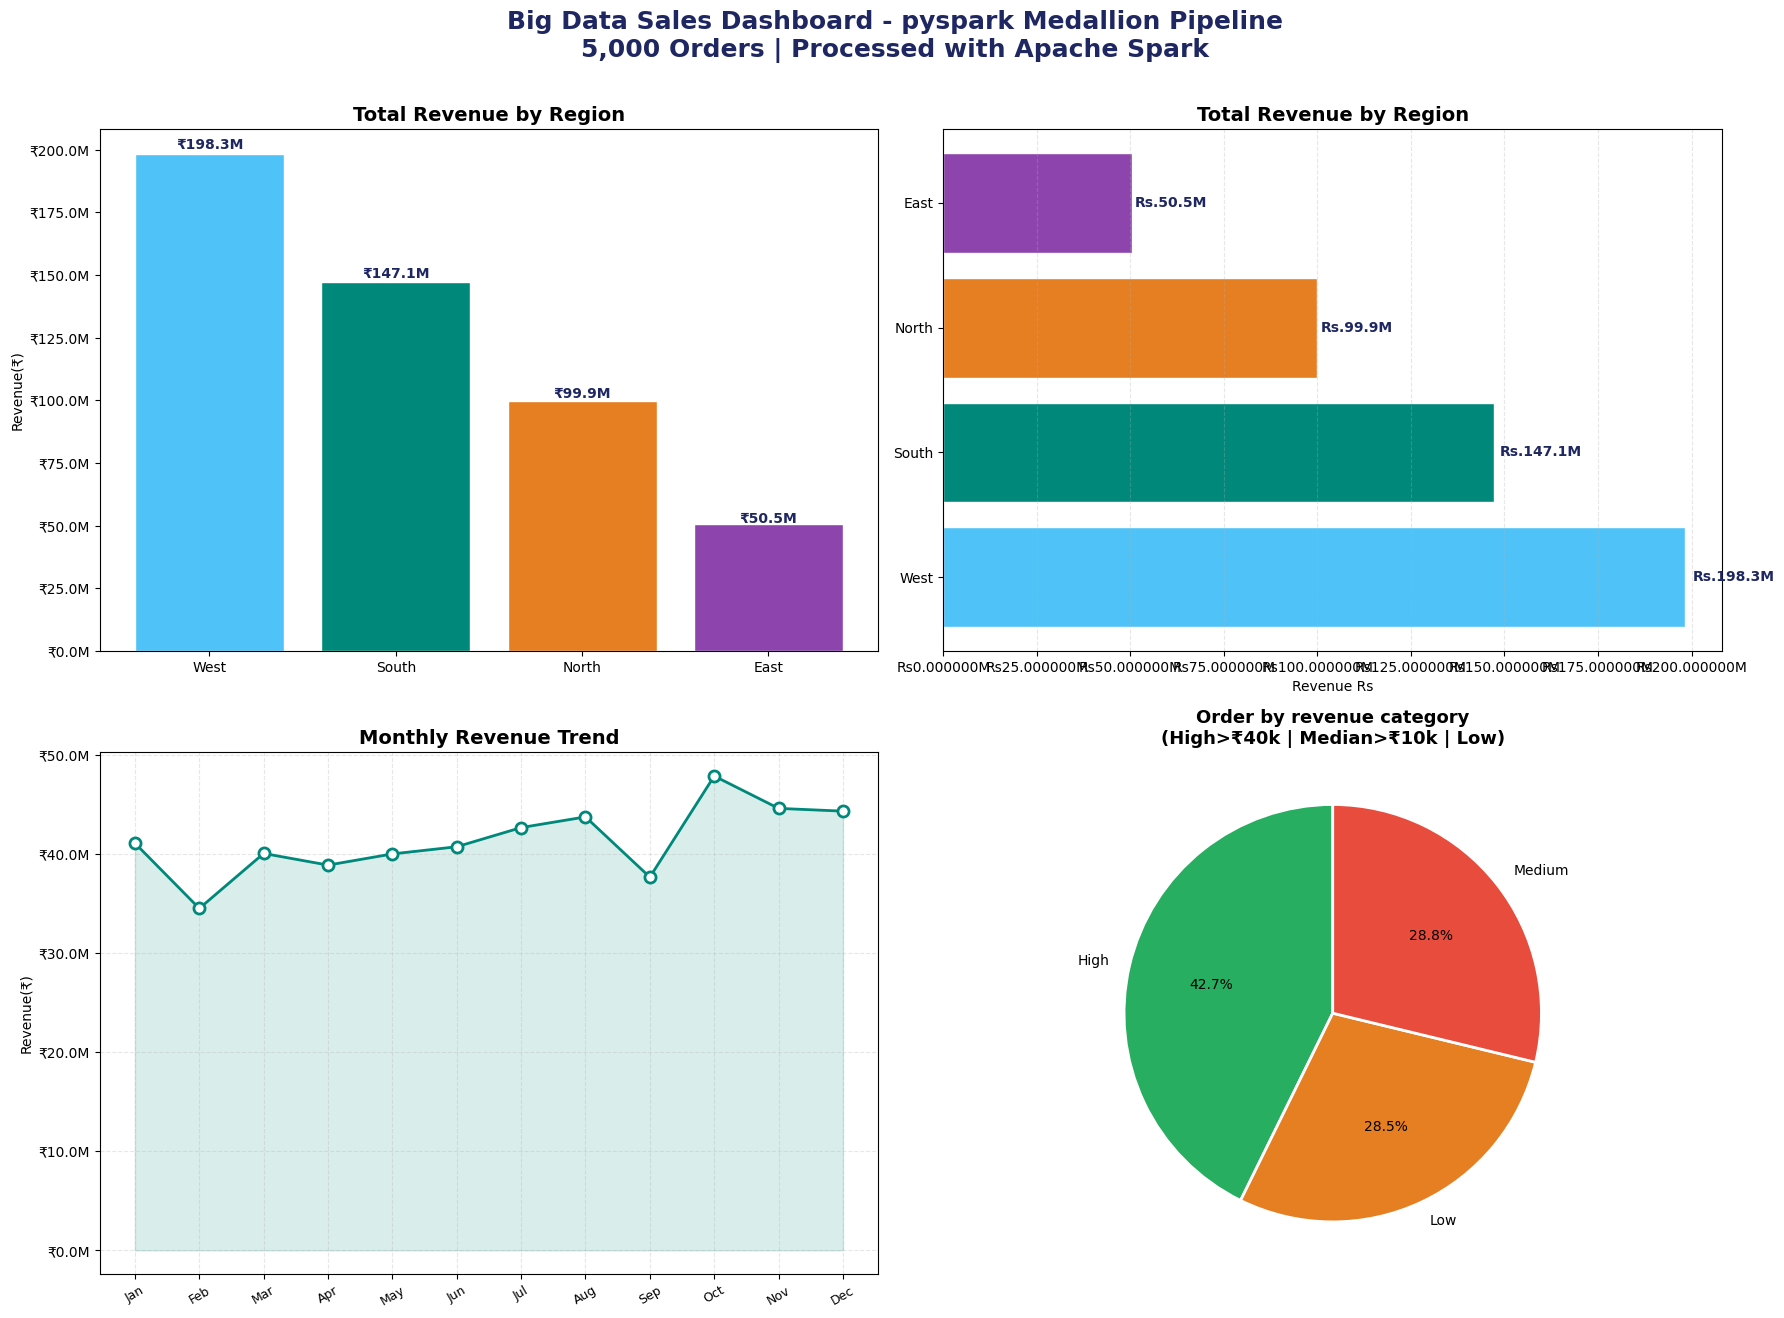

Dashboard saved:big_data_dashboard.png


In [67]:
fig,axes=plt.subplots(2,2,figsize=(18,13))
fig.suptitle(
    'Big Data Sales Dashboard - pyspark Medallion Pipeline\n'
    '5,000 Orders | Processed with Apache Spark',
    fontsize=18,fontweight='bold',color='#1E2761',y=1.01
)
colors4=['#4FC3F7','#00897B','#E67E22','#8E44AD','#E74C3C']

#-- panel1:Revenue by region --
ax1=axes[0][0]
bars1 = ax1.bar(region_pd['region'],region_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars1:
  ax1.text(
      bar.get_x()+bar.get_width()/2,
      bar.get_height()*1.01,
      f'₹{bar.get_height()/1e6:.1f}M',
      ha='center',fontsize=10,fontweight='bold',color='#1E2761')
  ax1.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
  ax1.set_ylabel('Revenue(₹)')
  ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))

#-- panel2:Top Product Horizontal Bar --

ax2=axes[0][1] # Corrected: Assign ax2 to a specific Axes object from the array
bars2=ax2.barh(region_pd['region'],region_pd['total_revenue'],
              color=colors4[:len(region_pd)], edgecolor='white')
for bar in bars2:
  ax2.text(
      bar.get_width() * 1.01, # x-position: just after the bar end
      bar.get_y() + bar.get_height() / 2, # y-position: centered on the bar
      f'Rs.{bar.get_width()/1e6:.1f}M', # text content: display bar width (revenue)
      ha='left', # horizontal alignment
      va='center', # vertical alignment
      fontsize=10,
      fontweight='bold',
      color='#1E2761'
  )

ax2.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
ax2.set_xlabel('Revenue Rs') # changed to xlabel for barh
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'Rs{x/1e6:1f}M')) # changed to xaxis

ax2.grid(axis='x',alpha=0.3,linestyle='--') # changed to axis='x'

#plot diagram to retrieve monthly label based on revenue
ax3=axes[1][0]
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Create a mapping from full month names (as they appear in monthly_pd) to numerical month values
full_month_names_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

# Convert 'order_month' to numerical values and sort chronologically
monthly_pd['numerical_month'] = monthly_pd['order_month'].map(full_month_names_map)
monthly_pd = monthly_pd.sort_values('numerical_month').reset_index(drop=True)

# Now generate monthly_labels using the numerical month and the month_names list
monthly_labels=[month_names[m-1] for m in monthly_pd['numerical_month']]

ax3.plot(monthly_labels,monthly_pd['monthly_revenue'],marker='o',linewidth=2,color='#00897B',markersize=8,markerfacecolor='white',markeredgewidth=2)
ax3.fill_between(range(len(monthly_labels)),monthly_pd['monthly_revenue'],alpha=0.15,color='#00897B')
ax3.set_title('Monthly Revenue Trend',fontsize=14,fontweight='bold')
ax3.set_ylabel('Revenue(₹)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'₹{y/1e6:.1f}M'))
ax3.grid(alpha=0.3,linestyle='--')
ax3.tick_params(axis='x',rotation=30, labelsize=9)

ax4=axes[1][1]
rev_cat=df_silver.groupBy('revenue_category') \
  .count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],labels=rev_cat['revenue_category'],
        colors=['#27AE60','#E67e22','#E74C3C'],autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Order by revenue category\n(High>₹40k | Median>₹10k | Low)',fontsize=13,fontweight='bold')

plt.tight_layout()
plt.savefig('big_data_dashboard.png',dpi=150,bbox_inches='tight')
plt.show()
print('Dashboard saved:big_data_dashboard.png')